In [1]:
from scipy.stats import norm
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

from class_imbalance_experiment.util import run_experiment, multiclass_imbalance_ratio

np.random.seed(42)

n_samples = 10000

# Class distribution
class_distribution = [0.45, 0.045, 0.015, 0.04, 0.45]
classes = np.arange(1, 6)

le = LabelEncoder()
le.fit(classes)

# Latent variable
z = np.random.normal(0, 1.0, n_samples)

# Find thresholds according to distribution
cum_probs = np.cumsum(class_distribution)
thresholds = np.concatenate(([-np.inf],norm.ppf(cum_probs)))
y = np.searchsorted(thresholds, z, side="right")

print(thresholds)

# Generate ordinal target
#y = np.random.choice(classes, size=n_samples, p=class_distribution)

print("Imbalance Ratio (IR) ", multiclass_imbalance_ratio(y))

# Create features
X1 = z + np.random.normal(0, 1.0, n_samples)
X2 = np.sin(z) + np.random.normal(0, 1.0, n_samples)
X3 = 0.8 * z + np.random.normal(0, 0.2, n_samples)
X4 = 0.5 * z + np.random.normal(0, 0.3, n_samples)

# Combine into a DataFrame
data = pd.DataFrame({
    'feature_1': X1,
    'feature_2': X2,
    'feature_3': X3,
    'feature_4': X4,
    'class': y
})

# Assuming `data` DataFrame exists
X = data.drop(columns='class')
y = data['class']


[       -inf -0.12566135 -0.01253347  0.02506891  0.12566135         inf]
Imbalance Ratio (IR)  29.25974025974026


In [15]:
# Overall class distribution
print("\nClass distribution in full dataset:")
print(data['class'].value_counts(normalize=True).sort_index())


Class distribution in full dataset:
class
1   0.45060
2   0.04580
3   0.01540
4   0.03840
5   0.44980
Name: proportion, dtype: float64


C:\Users\Q454199\projects\ordinal-aleatoric-epistemic-uncertainty\class_imbalance_experiment\util.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(x=[1,2,3,4,5],y=p,legend=False,palette=colors)


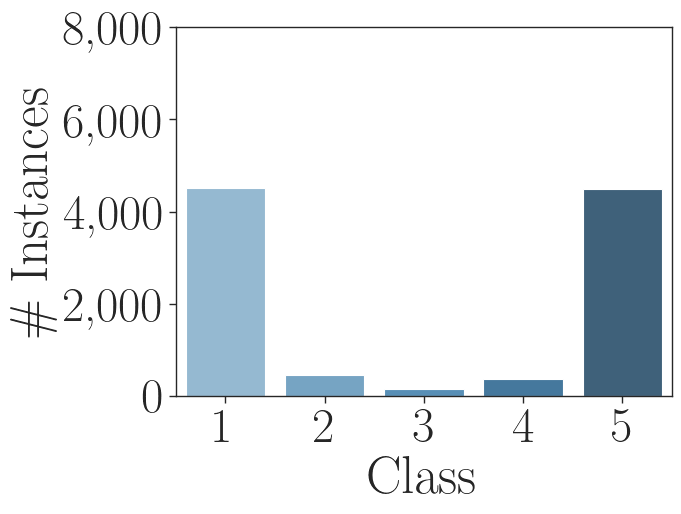

In [18]:
from class_imbalance_experiment.util import plot_data_dist

plot_data_dist(data['class'].value_counts(normalize=False).sort_index().values , "bimodal")

In [17]:
run_experiment(X, y, le, "bimodal")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000172 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 9000, number of used features: 4
[LightGBM] [Info] Start training from score -0.797274
[LightGBM] [Info] Start training from score -3.083957
[LightGBM] [Info] Start training from score -4.170506
[LightGBM] [Info] Start training from score -3.258541
[LightGBM] [Info] Start training from score -0.799002
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000227 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 9000, number of used features: 4
[LightGBM] [Info] Start training from score -0.797274
[LightGBM] [Info] Start training from score -3.083957
[LightGBM] [Info] Start training from score -4.1